# Классификация музыкальных произведений по жанрам

## Подготовка данных

### Импорт библитек

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
pip install phik

Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install scikit-learn==1.1.3

  Using cached scikit_learn-1.1.3-cp38-cp38-macosx_10_9_x86_64.whl (8.6 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2


In [6]:
pip install --upgrade scikit-learn

  Using cached scikit_learn-1.3.2-cp38-cp38-macosx_10_9_x86_64.whl (10.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.1.3
    Uninstalling scikit-learn-1.1.3:
      Successfully uninstalled scikit-learn-1.1.3
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install catboost==<desired_version> --install-option="--with-gpu"

zsh:1: no such file or directory: desired_version
Note: you may need to restart the kernel to use updated packages.


In [8]:
from sklearn.pipeline import Pipeline, make_pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from phik import report
from sklearn.metrics import (
    f1_score,
    make_scorer)

from collections import Counter
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from catboost import CatBoostClassifier

### Загрузка данных

In [42]:
# Загрузим файлы с тренировочной выборкой (kaggle_music_genre_train.csv) и тестовой (kaggle_music_genre_test.csv)
try:
    data_train = pd.read_csv('/Users/lena/kaggle_music_genre_train.csv')
    data_test = pd.read_csv('/Users/lena/kaggle_music_genre_test.csv')
except:
    data_train = pd.read_csv('/kaggle/input/music-genre-prediction-m120ds/kaggle_music_genre_train.csv')
    data_test = pd.read_csv('/kaggle/input/music-genre-prediction-m120ds/kaggle_music_genre_test.csv')

In [43]:
# Откроем датасет с тренировочной выборкой data_train
data_train.head()

,instance_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,25143.0,Highwayman,0.4800,0.670,182653.0,0.351,0.017600,D,0.115,-16.842,Major,0.0463,101.384,4-Apr,0.450,Country
1,26091.0,Toes Across The Floor,0.2430,0.452,187133.0,0.670,0.000051,A,0.108,-8.392,Minor,0.0352,113.071,4-Apr,0.539,Rock
2,87888.0,First Person on Earth,0.2280,0.454,173448.0,0.804,0.000000,E,0.181,-5.225,Minor,0.3710,80.980,4-Apr,0.344,Alternative
3,77021.0,No Te Veo - Digital Single,0.0558,0.847,255987.0,0.873,0.000003,G#,0.325,-4.805,Minor,0.0804,116.007,4-Apr,0.966,Hip-Hop
4,20852.0,Chasing Shadows,0.2270,0.742,195333.0,0.575,0.000002,C,0.176,-5.550,Major,0.0487,76.494,4-Apr,0.583,Alternative


In [44]:
# Откроем датасет с тестовой выборкой data_test
data_test.head()

,instance_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence
0,48564,Low Class Conspiracy,0.301000,0.757,146213.0,0.679,0.00000,A#,0.3030,-7.136,Minor,0.3560,90.361,4-Apr,0.895
1,72394,The Hunter,0.538000,0.256,240360.0,0.523,0.00832,G#,0.0849,-5.175,Major,0.0294,78.385,4-Apr,0.318
2,88081,Hate Me Now,0.005830,0.678,284000.0,0.770,0.00000,A,0.1090,-4.399,Minor,0.2220,90.000,4-Apr,0.412
3,78331,Somebody Ain't You,0.020300,0.592,177354.0,0.749,0.00000,B,0.1220,-4.604,Major,0.0483,160.046,4-Apr,0.614
4,72636,Sour Mango,0.000335,0.421,-1.0,0.447,0.01480,D,0.0374,-8.833,Major,0.2020,73.830,4-Apr,0.121


## Предобработка данных

In [45]:
# Посмотрим информацию data_train
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20394 entries, 0 to 20393
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       20394 non-null  float64
 1   track_name        20394 non-null  object 
 2   acousticness      20394 non-null  float64
 3   danceability      20394 non-null  float64
 4   duration_ms       20394 non-null  float64
 5   energy            20394 non-null  float64
 6   instrumentalness  20394 non-null  float64
 7   key               19659 non-null  object 
 8   liveness          20394 non-null  float64
 9   loudness          20394 non-null  float64
 10  mode              19888 non-null  object 
 11  speechiness       20394 non-null  float64
 12  tempo             19952 non-null  float64
 13  obtained_date     20394 non-null  object 
 14  valence           20394 non-null  float64
 15  music_genre       20394 non-null  object 
dtypes: float64(11), object(5)
memory usage: 

In [46]:
# Посмотрим информацию data_test
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       5099 non-null   int64  
 1   track_name        5099 non-null   object 
 2   acousticness      5099 non-null   float64
 3   danceability      5099 non-null   float64
 4   duration_ms       5099 non-null   float64
 5   energy            5099 non-null   float64
 6   instrumentalness  5099 non-null   float64
 7   key               4941 non-null   object 
 8   liveness          5099 non-null   float64
 9   loudness          5099 non-null   float64
 10  mode              4950 non-null   object 
 11  speechiness       5099 non-null   float64
 12  tempo             4978 non-null   float64
 13  obtained_date     5099 non-null   object 
 14  valence           5099 non-null   float64
dtypes: float64(10), int64(1), object(4)
memory usage: 597.7+ KB


Датасет data_train содержит 16 колонок и 20394 значений.  
Датасет data_test содержит 15 колонок и 5099 значений (отсутствует целевой признак 'music_genre').  

Все признаки можно разбить на:  


**Количественные признаки:**
  
* acousticness - акустичность  
* danceability - танцевальность  
* duration_ms -продолжительность в милисекундах  
* energy - энергичность  
* instrumentalness - инструментальность  
* liveness - привлекательность  
* loudness - громкость  
* speechiness - выразительность  
* tempo - темп  
* valence - привлекательность произведения для пользователей сервиса  

**Качественные признаки**

* instance_id - уникальный идентификатор трека
* track_name - название трека  
* key - базовый ключ (нота) произведения  
* mode - указывает на модальность (мажорную или минорную) трека  
* obtained_date - дата загрузки в сервис  
* music_genre - музыкальный жанр  

**Проверим датасеты на пропуски**

In [47]:
data_train.isna().sum()

instance_id           0
track_name            0
acousticness          0
danceability          0
duration_ms           0
energy                0
instrumentalness      0
key                 735
liveness              0
loudness              0
mode                506
speechiness           0
tempo               442
obtained_date         0
valence               0
music_genre           0
dtype: int64

В датасете data_train есть пропуски в колонках: key, mode и tempo.  
Заменим пропуски в категориальных значениях заглушкой 'unknown', числовые - медианными значениями.

In [48]:
data_train['key'] = data_train['key'].fillna('unknown')
data_train['mode'] = data_train['mode'].fillna('unknown')
data_train['tempo'] = data_train['tempo'].fillna(data_train['tempo'].median())

In [49]:
# Проверим пропуски еще раз после внесенных изменений
data_train.isna().sum()

instance_id         0
track_name          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
obtained_date       0
valence             0
music_genre         0
dtype: int64

In [50]:
# Проверим датасет data_test на пропуски
data_test.isna().sum()

instance_id           0
track_name            0
acousticness          0
danceability          0
duration_ms           0
energy                0
instrumentalness      0
key                 158
liveness              0
loudness              0
mode                149
speechiness           0
tempo               121
obtained_date         0
valence               0
dtype: int64

В датасете data_test также есть пропуски в колонках: key, mode и tempo.
Заменим пропуски в категориальных значениях заглушкой 'unknown', числовые - медианными значениями.

In [51]:
data_test['key'] = data_test['key'].fillna('unknown')
data_test['mode'] = data_test['mode'].fillna('unknown')
data_test['tempo'] = data_test['tempo'].fillna(data_test['tempo'].median())

In [52]:
# Проверим пропуски еще раз после внесенных изменений
data_test.isna().sum()

instance_id         0
track_name          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
obtained_date       0
valence             0
dtype: int64

**Проверим датасет data_train на явные дубликаты**

In [53]:
# В data_train явных дубликатов не обнаружено
data_train.duplicated().sum()

0

In [54]:
# В data_test явных дубликатов не обнаружено
data_test.duplicated().sum()

0

**Проверим категориальные значения по отдельности**

In [22]:
# Все 'instance_id' в data_train уникальны
data_train['instance_id'].nunique()

20394

In [23]:
# 4 уникальные даты
data_train['obtained_date'].unique()

array(['4-Apr', '3-Apr', '5-Apr', '1-Apr'], dtype=object)

In [41]:
# Будем считать, что все базовые ключи (ноты) в колонке 'key' уникальны, знак '#' на 'диез'
# Справка Википедии: В музыкальной нотации дие́з — знак альтерации, обозначающий повышение стоящих 
# справа от него нот на один хроматический полутон. Ставится либо после ключа, либо перед отдельными нотами. 
# В первом случае действует до следующего ключа, во втором — до конца такта или явной отмены знаком бекар. 
# Диез обозначается решёткой.

data_train['key'].unique()

array(['D', 'A', 'E', 'G#', 'C', 'D#', 'A#', 'F', 'F#', 'unknown', 'G',
       'C#', 'B'], dtype=object)

In [34]:
# Модальности (мажорная или минорная) треков: 'Major', 'Minor', 'unknown' - неизвестные значения.
data_train['mode'].unique()

array(['Major', 'Minor', 'unknown'], dtype=object)

In [36]:
# Есть повторяющиеся названия композиций, это вполне вероятно (у разных групп или артистов могут выходить треки с
# одинаковыми заголовками)

data_train['track_name'].value_counts()

Home                         11
Summertime                    7
Diamonds                      7
Forever                       6
Save Me                       6
                             ..
Habits                        1
Rank Strangers                1
If You Ever (feat. 6LACK)     1
Oi-1                          1
Harper Valley P.T.A.          1
Name: track_name, Length: 18643, dtype: int64

In [37]:
# 10 уникальных музыкальных жанра. Именно их нам предстоит предсказать для другого датасета data_test
data_train['music_genre'].value_counts()

Blues          2858
Alternative    2601
Electronic     2564
Rap            2428
Rock           2165
Country        2120
Anime          1901
Classical      1373
Jazz           1239
Hip-Hop        1145
Name: music_genre, dtype: int64

Точно так же проверим категориальные данные в data_test

In [56]:
# Все 'instance_id' в data_train уникальны
data_test['instance_id'].nunique()

5099

In [57]:
# 4 уникальные даты
data_test['obtained_date'].unique()

array(['4-Apr', '3-Apr', '5-Apr', '1-Apr'], dtype=object)

In [58]:
data_test['key'].unique()

array(['A#', 'G#', 'A', 'B', 'D', 'F#', 'F', 'G', 'C', 'unknown', 'D#',
       'C#', 'E'], dtype=object)

In [59]:
data_test['mode'].unique()

array(['Minor', 'Major', 'unknown'], dtype=object)

In [60]:
data_test['track_name'].value_counts()

Better Days                          3
No Love                              3
Maybe                                3
Sorry                                3
Black Holes (Solid Ground)           3
                                    ..
Polka Dots And Moonbeams             1
Love in the Middle of a Firefight    1
Stifled                              1
ヴィランの侵攻                              1
Fancy                                1
Name: track_name, Length: 4981, dtype: int64

In [38]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20394 entries, 0 to 20393
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       20394 non-null  float64
 1   track_name        20394 non-null  object 
 2   acousticness      20394 non-null  float64
 3   danceability      20394 non-null  float64
 4   duration_ms       20394 non-null  float64
 5   energy            20394 non-null  float64
 6   instrumentalness  20394 non-null  float64
 7   key               20394 non-null  object 
 8   liveness          20394 non-null  float64
 9   loudness          20394 non-null  float64
 10  mode              20394 non-null  object 
 11  speechiness       20394 non-null  float64
 12  tempo             20394 non-null  float64
 13  obtained_date     20394 non-null  object 
 14  valence           20394 non-null  float64
 15  music_genre       20394 non-null  object 
dtypes: float64(11), object(5)
memory usage: 

In [40]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       5099 non-null   int64  
 1   track_name        5099 non-null   object 
 2   acousticness      5099 non-null   float64
 3   danceability      5099 non-null   float64
 4   duration_ms       5099 non-null   float64
 5   energy            5099 non-null   float64
 6   instrumentalness  5099 non-null   float64
 7   key               5099 non-null   object 
 8   liveness          5099 non-null   float64
 9   loudness          5099 non-null   float64
 10  mode              5099 non-null   object 
 11  speechiness       5099 non-null   float64
 12  tempo             5099 non-null   float64
 13  obtained_date     5099 non-null   object 
 14  valence           5099 non-null   float64
dtypes: float64(10), int64(1), object(4)
memory usage: 597.7+ KB


## Исследовательский анализ данных

**Посмотрим количественные значения**

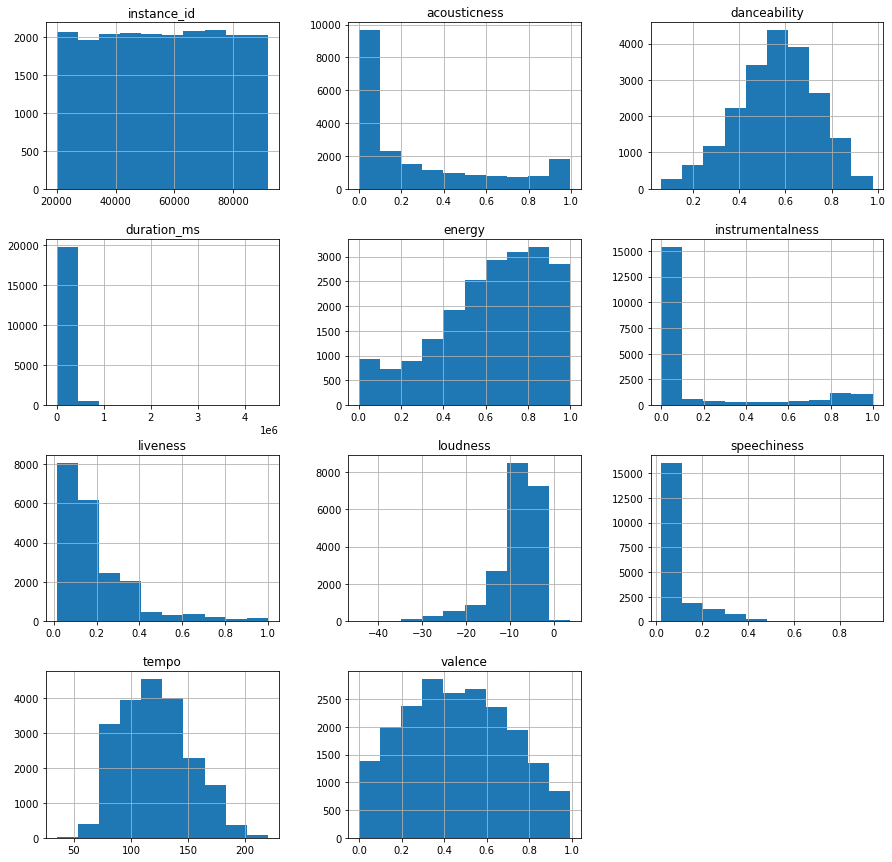

In [61]:
#Гистограмма для датасета data_train
data_train.hist(figsize=(15, 15));

In [62]:
# Общая информация о всех количественных признаках
data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
instance_id,20394.0,55973.846916,20695.792545,20011.00000,38157.25000,56030.000000,73912.750000,91758.000
acousticness,20394.0,0.274783,0.321643,0.00000,0.01520,0.120000,0.470000,0.996
danceability,20394.0,0.561983,0.171898,0.06000,0.45100,0.570000,0.683000,0.978
duration_ms,20394.0,220375.425272,126728.326142,-1.00000,177517.00000,219533.000000,266000.000000,4497994.000
energy,20394.0,0.625276,0.251238,0.00101,0.47000,0.666000,0.830000,0.999
instrumentalness,20394.0,0.159989,0.306503,0.00000,0.00000,0.000144,0.084475,0.996
liveness,20394.0,0.198540,0.166742,0.01360,0.09730,0.130000,0.253000,1.000
loudness,20394.0,-8.552998,5.499917,-44.40600,-10.25575,-7.052000,-5.054000,3.744
speechiness,20394.0,0.091352,0.097735,0.02230,0.03560,0.049050,0.095575,0.942
tempo,20394.0,120.922366,30.096343,34.76500,96.02850,120.012500,140.974000,220.041


Данные стремятся к нормальному распределению у признаков:  

danceability - танцевальность  
tempo - темп  
valence - привлекательность произведения для пользователей сервиса  

Есть выбросы у некоторых количественных значений:  
 
acousticness - акустичность  
duration_ms -продолжительность в милисекундах  
instrumentalness - инструментальность  
liveness - привлекательность  
loudness - громкость  
speechiness - выразительность  
  
Аномалия, бросающаяся в глаза duration_ms с отрицательным значением.   

Необходимо будет обработать эти значения.  

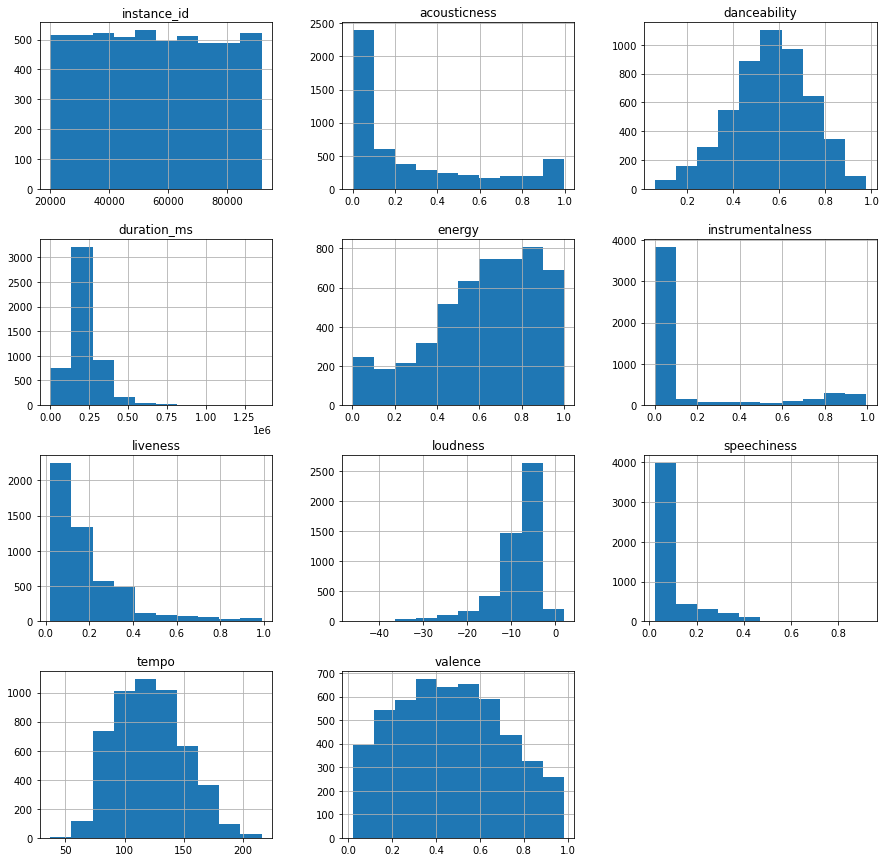

In [63]:
#Гистограмма для датасета data_test
data_test.hist(figsize=(15, 15));

In [64]:
data_test.describe().T

,count,mean,std,min,25%,50%,75%,max
instance_id,5099.0,55643.871347,20762.384803,20012.000000,37571.00000,55246.000000,73702.00000,91709.000
acousticness,5099.0,0.276324,0.322657,0.000002,0.01660,0.120000,0.46000,0.996
danceability,5099.0,0.561888,0.170502,0.059600,0.45100,0.568000,0.68100,0.977
duration_ms,5099.0,217397.407727,115637.408282,-1.000000,173733.50000,217500.000000,264247.00000,1360027.000
energy,5099.0,0.622030,0.251829,0.001540,0.46500,0.660000,0.82600,0.999
instrumentalness,5099.0,0.165198,0.311940,0.000000,0.00000,0.000157,0.09275,0.994
liveness,5099.0,0.197924,0.166241,0.020400,0.09695,0.129000,0.24800,0.990
loudness,5099.0,-8.630186,5.619766,-46.122000,-10.23100,-7.135000,-5.12700,1.949
speechiness,5099.0,0.092718,0.100130,0.022600,0.03570,0.048700,0.09655,0.918
tempo,5099.0,121.218154,29.519830,37.114000,96.73250,120.053500,141.00250,216.029


Данные стремятся к нормальному распределению у признаков:  

danceability - танцевальность  
tempo - темп  
valence - привлекательность произведения для пользователей сервиса  
  
Есть выбросы у некоторых количественных значений:  

acousticness - акустичность  
duration_ms -продолжительность в милисекундах  
instrumentalness - инструментальность  
liveness - привлекательность  
loudness - громкость  
speechiness - выразительность  

Аномалия, бросающаяся в глаза duration_ms с отрицательным значением.  

Однако обрабатывать, удалять аномалии и выбросы в data_test не будем, так как нам необходимо сохранить все значения, чтобы предсказать музыкальный жанр для всех значений.

In [65]:
# Посмотрим количество отрицательных значений в колонке 'duration_ms'
data_train['duration_ms'].value_counts()

-1.0         2009
 240000.0      16
 192000.0      16
 180000.0      13
 182400.0      10
             ... 
 196774.0       1
 192009.0       1
 249387.0       1
 231231.0       1
 316433.0       1
Name: duration_ms, Length: 13649, dtype: int64

In [66]:
# Удалим 2009 значений с -1
data_train = data_train.drop(data_train[data_train['duration_ms'] == -1].index)

In [67]:
data_train['duration_ms'].value_counts()

240000.0    16
192000.0    16
180000.0    13
182400.0    10
191000.0     9
            ..
221453.0     1
196774.0     1
192009.0     1
249387.0     1
316433.0     1
Name: duration_ms, Length: 13648, dtype: int64

In [68]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18385 entries, 0 to 20393
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       18385 non-null  float64
 1   track_name        18385 non-null  object 
 2   acousticness      18385 non-null  float64
 3   danceability      18385 non-null  float64
 4   duration_ms       18385 non-null  float64
 5   energy            18385 non-null  float64
 6   instrumentalness  18385 non-null  float64
 7   key               18385 non-null  object 
 8   liveness          18385 non-null  float64
 9   loudness          18385 non-null  float64
 10  mode              18385 non-null  object 
 11  speechiness       18385 non-null  float64
 12  tempo             18385 non-null  float64
 13  obtained_date     18385 non-null  object 
 14  valence           18385 non-null  float64
 15  music_genre       18385 non-null  object 
dtypes: float64(11), object(5)
memory usage: 

Проверим количественные признаки по-отдельности:

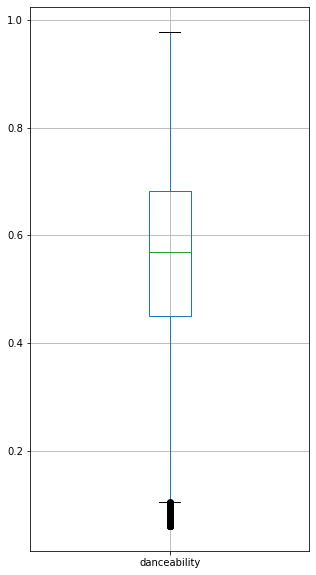

In [69]:
data_train['danceability'].plot(kind='box',
                             figsize=(5,10), 
                             grid=True, 
                             legend=True, 
                             title='');

In [70]:
# Удалим выбросы
data_train = data_train.drop(data_train[data_train['danceability'] < 0.15].index)

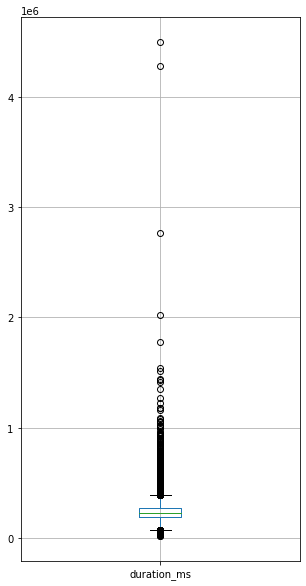

In [71]:
data_train['duration_ms'].plot(kind='box',
                             figsize=(5,10), 
                             grid=True, 
                             legend=True, 
                             title='');

In [72]:
# Удалим выбросы
data_train = data_train.drop(data_train[data_train['duration_ms'] > 360000].index)
data_train = data_train.drop(data_train[data_train['duration_ms'] < 103000].index)

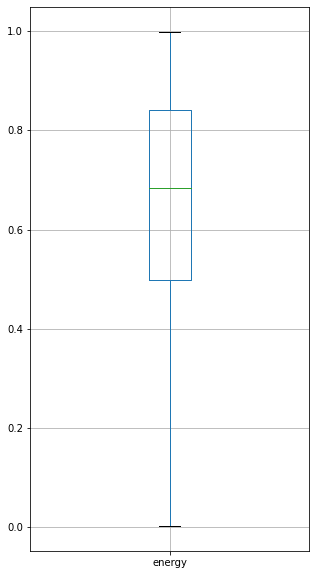

In [75]:
# Нет выбросов
data_train['energy'].plot(kind='box',
                             figsize=(5,10), 
                             grid=True, 
                             legend=True, 
                             title='');

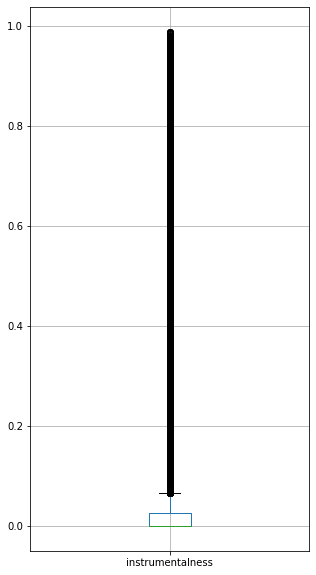

In [76]:
data_train['instrumentalness'].plot(kind='box',
                             figsize=(5,10), 
                             grid=True, 
                             legend=True, 
                             title='');

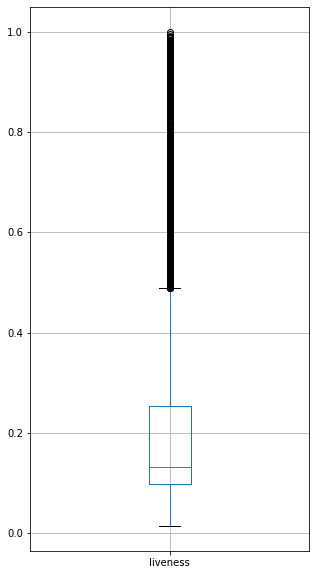

In [46]:
data_train['liveness'].plot(kind='box',
                             figsize=(5,10), 
                             grid=True, 
                             legend=True, 
                             title='');

In [77]:
# Удалим выбросы
data_train = data_train.drop(data_train[data_train['liveness'] > 0.45].index)

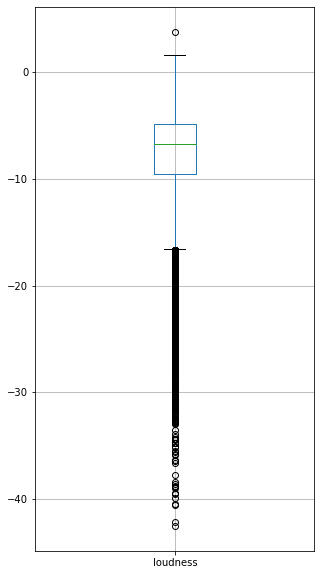

In [78]:
data_train['loudness'].plot(kind='box',
                             figsize=(5,10), 
                             grid=True, 
                             legend=True, 
                             title='');

In [79]:
# Удалим выбросы
data_train = data_train.drop(data_train[data_train['loudness'] > 0.2].index)
data_train = data_train.drop(data_train[data_train['loudness'] < -35].index)

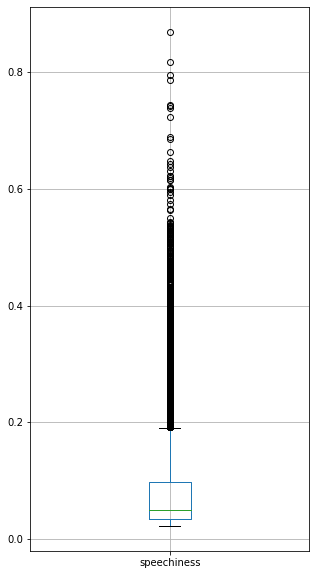

In [80]:
data_train['speechiness'].plot(kind='box',
                             figsize=(5,10), 
                             grid=True, 
                             legend=True, 
                             title='');

In [81]:
# Удалим выбросы
data_train = data_train.drop(data_train[data_train['speechiness'] > 0.47].index)

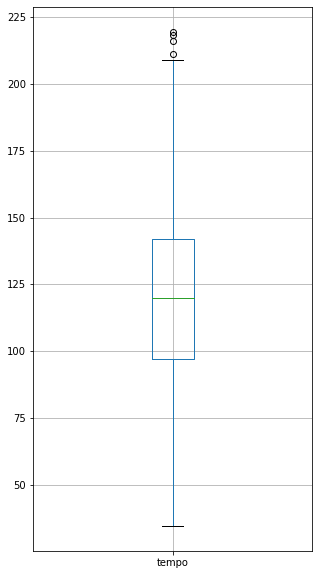

In [82]:
data_train['tempo'].plot(kind='box',
                             figsize=(5,10), 
                             grid=True, 
                             legend=True, 
                             title='');

In [83]:
# Удалим выбросы
data_train = data_train.drop(data_train[data_train['tempo'] > 205].index)

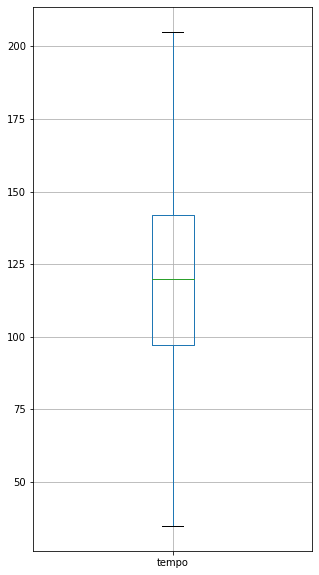

In [84]:
data_train['tempo'].plot(kind='box',
                             figsize=(5,10), 
                             grid=True, 
                             legend=True, 
                             title='');

In [86]:
# Проверим количество оставшихся значений после очистки датасета data_train
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15179 entries, 0 to 20393
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       15179 non-null  float64
 1   track_name        15179 non-null  object 
 2   acousticness      15179 non-null  float64
 3   danceability      15179 non-null  float64
 4   duration_ms       15179 non-null  float64
 5   energy            15179 non-null  float64
 6   instrumentalness  15179 non-null  float64
 7   key               15179 non-null  object 
 8   liveness          15179 non-null  float64
 9   loudness          15179 non-null  float64
 10  mode              15179 non-null  object 
 11  speechiness       15179 non-null  float64
 12  tempo             15179 non-null  float64
 13  obtained_date     15179 non-null  object 
 14  valence           15179 non-null  float64
 15  music_genre       15179 non-null  object 
dtypes: float64(11), object(5)
memory usage: 

### Проверим все значения на мультиколлинеарность

Будем использовать phik, так как он позволяет обнаружить корреляцию не только между количественными, но и между качественными признаками

interval columns not set, guessing: ['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']


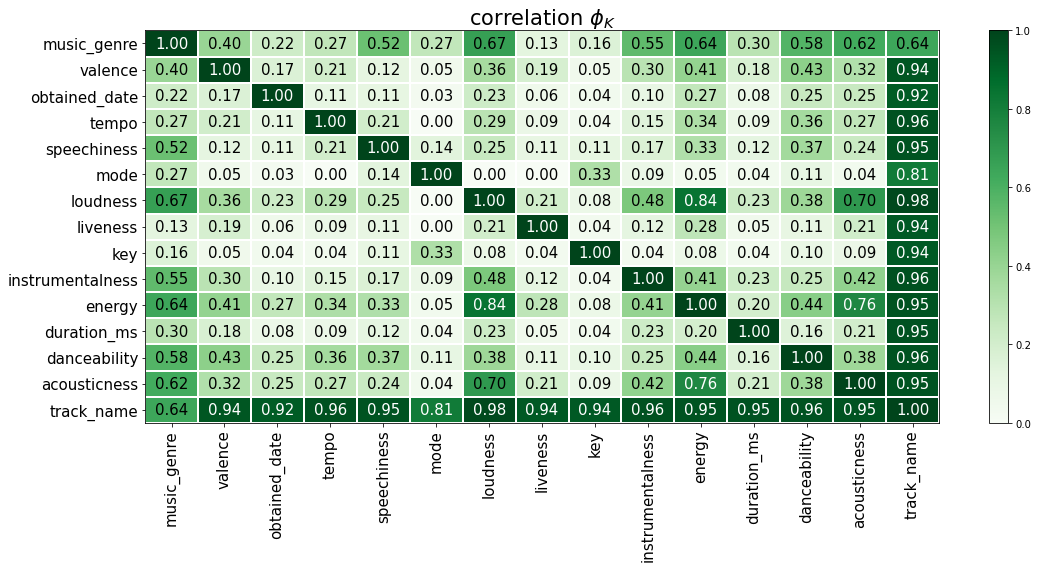

In [649]:
# Удалим 'instance_id', чтобы не усложнять обработку данных
data_temp = data_train.drop(['instance_id'], axis=1)

phik_overview = data_temp.phik_matrix()

plot_correlation_matrix(phik_overview.values, 
                        x_labels=phik_overview.columns, 
                        y_labels=phik_overview.index, 
                        vmin=0, vmax=1, color_map="Greens", 
                        title=r"correlation $\phi_K$", 
                        fontsize_factor=1.5, 
                        figsize=(16, 8))
plt.tight_layout();

Видим сильную корреляцию между:
* track-name и всеми признаками
* loudness и music_genre, energy, acousticness

Необходимо будет удалить признаки с сильной корреляцией, так как они будут негативно сказываться на обучении линейных моделей.

### Определим признаки, которые будем использовать для обучения моделей

Удалим лишние столбцы, которые не понадобяться на этапе обучения моделей:

**! При удалении loudness, или energy, или acousticness метрика f1 micro падала у логистической регрессии, поэтому было принято решение оставить все эти признаки** 

In [87]:
columns_to_drop = ['instance_id', 'track_name', 'obtained_date']

In [88]:
data_train = data_train.drop(columns=columns_to_drop, axis=1)
data_test = data_test.drop(columns=columns_to_drop, axis=1)

In [89]:
data_train.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,0.4800,0.670,182653.0,0.351,0.017600,D,0.115,-16.842,Major,0.0463,101.384,0.450,Country
1,0.2430,0.452,187133.0,0.670,0.000051,A,0.108,-8.392,Minor,0.0352,113.071,0.539,Rock
2,0.2280,0.454,173448.0,0.804,0.000000,E,0.181,-5.225,Minor,0.3710,80.980,0.344,Alternative
3,0.0558,0.847,255987.0,0.873,0.000003,G#,0.325,-4.805,Minor,0.0804,116.007,0.966,Hip-Hop
4,0.2270,0.742,195333.0,0.575,0.000002,C,0.176,-5.550,Major,0.0487,76.494,0.583,Alternative


In [90]:
data_test.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence
0,0.301000,0.757,146213.0,0.679,0.00000,A#,0.3030,-7.136,Minor,0.3560,90.361,0.895
1,0.538000,0.256,240360.0,0.523,0.00832,G#,0.0849,-5.175,Major,0.0294,78.385,0.318
2,0.005830,0.678,284000.0,0.770,0.00000,A,0.1090,-4.399,Minor,0.2220,90.000,0.412
3,0.020300,0.592,177354.0,0.749,0.00000,B,0.1220,-4.604,Major,0.0483,160.046,0.614
4,0.000335,0.421,-1.0,0.447,0.01480,D,0.0374,-8.833,Major,0.2020,73.830,0.121


In [92]:
# После удаления части признаков, проверим датасет на явные дубликаты
data_train.duplicated().sum()

6

In [93]:
# Удалим явные дубликаты
data_train = data_train.drop_duplicates()

In [94]:
data_train.duplicated().sum()

0

In [95]:
# Проверим оставшееся количество значений после очистки
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15173 entries, 0 to 20393
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      15173 non-null  float64
 1   danceability      15173 non-null  float64
 2   duration_ms       15173 non-null  float64
 3   energy            15173 non-null  float64
 4   instrumentalness  15173 non-null  float64
 5   key               15173 non-null  object 
 6   liveness          15173 non-null  float64
 7   loudness          15173 non-null  float64
 8   mode              15173 non-null  object 
 9   speechiness       15173 non-null  float64
 10  tempo             15173 non-null  float64
 11  valence           15173 non-null  float64
 12  music_genre       15173 non-null  object 
dtypes: float64(10), object(3)
memory usage: 1.6+ MB


In [97]:
# Проверим количество значений
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      5099 non-null   float64
 1   danceability      5099 non-null   float64
 2   duration_ms       5099 non-null   float64
 3   energy            5099 non-null   float64
 4   instrumentalness  5099 non-null   float64
 5   key               5099 non-null   object 
 6   liveness          5099 non-null   float64
 7   loudness          5099 non-null   float64
 8   mode              5099 non-null   object 
 9   speechiness       5099 non-null   float64
 10  tempo             5099 non-null   float64
 11  valence           5099 non-null   float64
dtypes: float64(10), object(2)
memory usage: 478.2+ KB


### Вывод

На этапе предобработки и исследовательского анализа данных:  

* Проверили датасеты на пропуски и явные дубликаты.  
Явных дубликатов обнаружено не было.  
  
* Обнаружили в датасете data_train пропуски в колонках: key, mode и tempo.  
Заменили пропуски в категориальных значениях заглушкой 'unknown', числовые - медианными значениями.  
  
* В датасете data_test также были обнаружены пропуски в колонках: key, mode и tempo. Заменили пропуски в категориальных  значениях заглушкой 'unknown', числовые - медианными значениями.  

* Отдельно проверили категориальные значения: аномалий не обнаружили.  

Проверили количественные значения в датасете data_train:  
* Удалили выбросы
* Удалили аномалии в колонке duration_ms с отрицательными значениями  

* Проверили все значения на мультиколлинеарность. Обнаружили сильную корреляцию между track-name и всеми признаками
и loudness и music_genre, energy, acousticness.
* Удалили значения 'instance_id', 'track_name', 'obtained_date', так как они не понадобяться на этапе обучения моделей

* При удалении loudness, или energy, или acousticness метрика f1 micro падала у логистической регрессии, поэтому было принято решение оставить эти признаки.  

## Обучение моделей

Целевой признак - 'music_genre' (музыкальный жанр).   
Нам предстоит решать задачу Классификации: классифицировать музыкальные произведения по жанрам.

Для работы возьмем 3 модели:
* LogisticRegression
* RandomForestClassifier
* CatBoostClassifier

Этап обучения моделей и выбора наилучшей осуществим с помощью облегченной версии Pipeline и GridSearchCV

In [66]:
# Разделим data_train на две выборки с целевым признаком 'music_genre' и без
X_train = data_train.drop(columns='music_genre')
y_train = data_train['music_genre']

# Разделим данные на обучающий и тестовый наборы с помощью train_test_split
X_train, _, y_train, _ = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Разделим признаки на категориальные и количественные

# Создадим 2 набора с категориальными признаками, так как для LogisticRegression мы будем использовать
# преобразование категориальных признаков в количественные с помощью OneHotEncoder, а для RandomForestClassifier
# и CatBoostClassifier - OrdinalEncoder.

categorical_features_lr = ['key', 'mode']  
categorical_features_rf_cb = ['key', 'mode']  

numeric_features = ['acousticness', 'danceability', 'duration_ms', 'energy', 
                    'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']  

# Создадим ColumnTransformer для применения преобразований к разным типам признаков 
# (количественные признаки будем масштабировать с помощью StandardScaler, качественные - с помощью OneHotEncoder
# и OrdinalEncoder)

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features_lr)
    ])

preprocessor_rf_cb = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OrdinalEncoder(), categorical_features_rf_cb)
    ])

In [68]:
# Определим пространство параметров для каждой модели

# Гиперпараметры для LogisticRegression
max_len_iter = 100
param_dist_lr = {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
                 'logisticregression__penalty': ['l1', 'l2'],
                 'logisticregression__random_state': [42],
                 'logisticregression__max_iter': list(range(10, max_len_iter + 1, 10)),
                 'logisticregression__solver': ['liblinear']}

# Гиперпараметры для RandomForestClassifier
param_dist_rf = {'randomforestclassifier__n_estimators': [10, 50, 100, 200],
                 'randomforestclassifier__max_depth': [None, 10, 20, 30],
                 'randomforestclassifier__min_samples_split': [2, 5, 10],
                 'randomforestclassifier__min_samples_leaf': [1, 2, 4],
                 'randomforestclassifier__random_state': [42]}

# Гиперпараметры для CatBoostClassifier
param_dist_catboost = {'catboostclassifier__iterations': [50, 100, 300],
                       'catboostclassifier__learning_rate': [0.01, 0.05, 0.1],
                       'catboostclassifier__depth': [4, 6, 8, 10],
                       'catboostclassifier__l2_leaf_reg': [1, 3, 5, 7, 9],
                       'catboostclassifier__border_count': [5, 10],
                       'catboostclassifier__thread_count': [4],
                       'catboostclassifier__random_state': [42]}

# GridSearchCV для поиска лучших гиперпараметров:

grid_lr = GridSearchCV(pipeline_lr, param_grid=param_dist_lr, cv=5, scoring='f1_micro', n_jobs=-1)
grid_rf = GridSearchCV(pipeline_rf, param_grid=param_dist_rf, cv=5, scoring='f1_micro', n_jobs=-1)
grid_catboost = GridSearchCV(pipeline_catboost, param_grid=param_dist_catboost, cv=5, scoring='f1_micro', n_jobs=-1)

# Обучим модели и провалидируем:
grid_lr.fit(X_train, y_train)
score_lr = grid_lr.best_score_

grid_rf.fit(X_train, y_train)
score_rf = grid_rf.best_score_

grid_catboost.fit(X_train, y_train)
score_catboost = grid_catboost.best_score_

# Выведем лучшие гиперпараметры и оценки каждой модели:
print(f'Best Logistic Regression Parameters: {grid_lr.best_params_}')
print(f'Logistic Regression Score: {score_lr}')

print(f'Best Random Forest Parameters: {grid_rf.best_params_}')
print(f'Random Forest Score: {score_rf}')

print(f'Best CatBoost Parameters: {grid_catboost.best_params_}')
print(f'CatBoost Score: {score_catboost}')

0:	learn: 2.2247108	total: 95.6ms	remaining: 28.6s
1:	learn: 2.1555676	total: 134ms	remaining: 19.9s
2:	learn: 2.1048928	total: 160ms	remaining: 15.8s
3:	learn: 2.0629887	total: 183ms	remaining: 13.5s
4:	learn: 2.0227476	total: 225ms	remaining: 13.3s
5:	learn: 1.9849636	total: 258ms	remaining: 12.6s
6:	learn: 1.9534713	total: 409ms	remaining: 17.1s
7:	learn: 1.9255540	total: 479ms	remaining: 17.5s
8:	learn: 1.8996793	total: 555ms	remaining: 17.9s
9:	learn: 1.8812936	total: 606ms	remaining: 17.6s
10:	learn: 1.8599494	total: 633ms	remaining: 16.6s
11:	learn: 1.8423758	total: 663ms	remaining: 15.9s
12:	learn: 1.8246580	total: 687ms	remaining: 15.2s
13:	learn: 1.8090644	total: 729ms	remaining: 14.9s
14:	learn: 1.7970346	total: 768ms	remaining: 14.6s
15:	learn: 1.7824751	total: 808ms	remaining: 14.3s
16:	learn: 1.7697746	total: 832ms	remaining: 13.8s
17:	learn: 1.7572193	total: 870ms	remaining: 13.6s
18:	learn: 1.7464376	total: 901ms	remaining: 13.3s
19:	learn: 1.7358019	total: 935ms	remain

161:	learn: 1.4210580	total: 9.06s	remaining: 7.72s
162:	learn: 1.4203105	total: 9.14s	remaining: 7.68s
163:	learn: 1.4197092	total: 9.21s	remaining: 7.63s
164:	learn: 1.4190152	total: 9.23s	remaining: 7.55s
165:	learn: 1.4182229	total: 9.27s	remaining: 7.49s
166:	learn: 1.4174660	total: 9.32s	remaining: 7.42s
167:	learn: 1.4165458	total: 9.36s	remaining: 7.36s
168:	learn: 1.4159754	total: 9.39s	remaining: 7.28s
169:	learn: 1.4153058	total: 9.42s	remaining: 7.21s
170:	learn: 1.4146819	total: 9.49s	remaining: 7.16s
171:	learn: 1.4138717	total: 9.53s	remaining: 7.09s
172:	learn: 1.4131560	total: 9.6s	remaining: 7.04s
173:	learn: 1.4126716	total: 9.62s	remaining: 6.97s
174:	learn: 1.4118322	total: 9.66s	remaining: 6.9s
175:	learn: 1.4108698	total: 9.69s	remaining: 6.83s
176:	learn: 1.4103292	total: 9.72s	remaining: 6.76s
177:	learn: 1.4098521	total: 9.75s	remaining: 6.68s
178:	learn: 1.4091492	total: 9.78s	remaining: 6.61s
179:	learn: 1.4085215	total: 9.81s	remaining: 6.54s
180:	learn: 1.

**Лучшие параметры f1 micro Logistic Regression:** 
'logisticregression__C': 1, 'logisticregression__max_iter': 30, 'logisticregression__penalty': 'l1', 'logisticregression__random_state': 42, 'logisticregression__solver': 'liblinear'
Score: 0.3819305123698797

**Лучшие параметры f1 micro Random Forest:** 
'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 200, 'randomforestclassifier__random_state': 42
Score: 0.4472274860464667

**Лучшие параметры f1 micro CatBoost:** 
'catboostclassifier__border_count': 10, 'catboostclassifier__depth': 4, 'catboostclassifier__iterations': 300, 'catboostclassifier__l2_leaf_reg': 9, 'catboostclassifier__learning_rate': 0.1, 'catboostclassifier__random_state': 42, 'catboostclassifier__thread_count': 4
Score: 0.45039170320013905

Таким образом, лучший результат показала модель CatBoost (f1 micro - 0.45). Ее возьмем для предсказаний на тестовой выборке.

In [73]:
# Предскажем целевой признак music_genre на тестовой выборке
X_test = data_test
predictions_catboost = grid_catboost.predict(X_test)

# Создадим DataFrame с instance_id и предсказанными значениями
data_test_with_instance_id = pd.read_csv('/Users/lena/kaggle_music_genre_test.csv', usecols=['instance_id'])
predictions_catboost = predictions_catboost.ravel()
result_df = pd.DataFrame({'instance_id': data_test_with_instance_id['instance_id'], 'music_genre': predictions_catboost})

# Сохраним DataFrame в CSV файл
result_df.to_csv('result_df_6.csv', index=False)

In [ ]:
try:
    result_df = pd.read_csv('/Users/lena/result_df_6.csv')
    data_test = pd.read_csv('/Users/lena/result_df_6.csv')
except:
    data_train = pd.read_csv('/kaggle/input/music-genre-prediction-m120ds/result_df_6.csv')
    data_test = pd.read_csv('/kaggle/input/music-genre-prediction-m120ds/result_df_6.csv')

In [822]:
result_df = pd.read_csv('/Users/lena/result_df_6.csv')
result_df.head()

,instance_id,music_genre
0,48564,Rap
1,72394,Blues
2,88081,Rap
3,78331,Country
4,72636,Rap


## Вывод

**На этапе предобработки и исследовательского анализа данных:**

* Проверили датасеты на пропуски и явные дубликаты.
Явных дубликатов обнаружено не было.

* Обнаружили в датасете data_train пропуски в колонках: key, mode и tempo.
Заменили пропуски в категориальных значениях заглушкой 'unknown', числовые - медианными значениями.

* В датасете data_test также были обнаружены пропуски в колонках: key, mode и tempo. Заменили пропуски в категориальных значениях заглушкой 'unknown', числовые - медианными значениями.

* Отдельно проверили категориальные значения: аномалий не обнаружили.

Проверили количественные значения в датасете data_train:

* Удалили выбросы
* Удалили аномалии в колонке duration_ms с отрицательными значениями

* Проверили все значения на мультиколлинеарность. Обнаружили сильную корреляцию между track-name и всеми признаками и loudness и music_genre, energy, acousticness.

* Удалили значения 'instance_id', 'track_name', 'obtained_date', так как они не понадобяться на этапе обучения моделей

* При удалении loudness, или energy, или acousticness метрика f1 micro падала у логистической регрессии, поэтому было принято решение оставить эти признаки.

**На этапе обучения моделей:**

Обучили три модели:
1. LogisticRegression
2. RandomForestClassifier
3. CatBoostClassifier

Лучший результат показала модель CatBoostClassifier: 'catboostclassifier__border_count': 10, 'catboostclassifier__depth': 4, 'catboostclassifier__iterations': 300, 'catboostclassifier__l2_leaf_reg': 9, 'catboostclassifier__learning_rate': 0.1, 'catboostclassifier__random_state': 42, 'catboostclassifier__thread_count': 4, f1 micro Score: 0.45039170320013905

Эту модель взяли для предсказаний на тестовой выборке

При загрузке финального решения на Kaggle получили F1 micro = 0.45900 на публичной таблице лидеров (Leaderboard), рассчитанной на ~50% тестовой выборки.
В приватной таблице лидеров, учитывающей оставшиеся 50% данных, итоговый результат составил F1 micro = 0.47882